In [206]:
import re
import numpy as np
from pathlib import Path

FLOAT = False
EXP = False
expon = 23 if FLOAT else (53 if EXP else 52)

# Path to the header file
path = Path("ziggurat_constants.h")
text = path.read_text()

# --- helpers -------------------------------------------------------------
def parse_uint32_array(name, text):
    m = re.search(
        rf"static const uint32_t {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"0x[0-9A-Fa-f]+", body)
    return np.array([int(v.rstrip("UL"), 16) for v in vals], dtype=np.uint32)


def parse_float_array(name, text):
    m = re.search(
        rf"static const float {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?", body)
    return np.array([v.rstrip("f") for v in vals], dtype=np.float32)


def parse_float_scalar(name, text):
    m = re.search(
        rf"static const float {name}\s*=\s*([-+]?\d*\.\d+(?:[eE][-+]?\d+)?f?);",
        text,
    )
    if not m:
        raise ValueError(f"Scalar {name} not found")
    return float(m.group(1).rstrip("f"))

def parse_uint64_array(name, text):
    m = re.search(
        rf"static const uint64_t {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"0x[0-9A-Fa-f]+(?:[uUlL]+)?", body)
    return np.array([int(re.sub(r"[uUlL]+$", "", v), 16) for v in vals], dtype=np.uint64)

def parse_double_array(name, text):
    m = re.search(
        rf"static const double {name}\[\] = \{{(.*?)\}};",
        text,
        re.S,
    )
    if not m:
        raise ValueError(f"Array {name} not found")
    body = m.group(1)
    vals = re.findall(r"[-+]?\d*\.\d+(?:[eE][-+]?\d+)?", body)
    return np.array(vals, dtype=np.float64)


def parse_double_scalar(name, text):
    m = re.search(
        rf"static const double {name}\s*=\s*([-+]?\d*\.\d+(?:[eE][-+]?\d+)?);",
        text,
    )
    if not m:
        raise ValueError(f"Scalar {name} not found")
    return float(m.group(1))

def f(x):
    return np.exp(-x) if EXP else np.exp(-x**2/2)
    
# --- parse everything ----------------------------------------------------
if FLOAT:
    if EXP:
        ki = parse_uint32_array("ke_float", text)
        wi = parse_float_array("we_float", text)
        fi = parse_float_array("fe_float", text)
        r = parse_float_scalar("ziggurat_exp_r_f", text)
    else:
        ki = parse_uint32_array("ki_float", text)
        wi = parse_float_array("wi_float", text)
        fi = parse_float_array("fi_float", text)
        r = parse_float_scalar("ziggurat_nor_r_f", text)
        inv_r = parse_float_scalar("ziggurat_nor_inv_r_f", text)
else:
    if EXP:
        ki = parse_uint64_array("ke_double", text)
        wi = parse_double_array("we_double", text)
        fi = parse_double_array("fe_double", text)
        r = parse_double_scalar("ziggurat_exp_r", text)
    else:
        ki = parse_uint64_array("ki_double", text)
        wi = parse_double_array("wi_double", text)
        fi = parse_double_array("fi_double", text)
        r = parse_double_scalar("ziggurat_nor_r", text)
        inv_r = parse_double_scalar("ziggurat_nor_inv_r", text)


# --- sanity prints -------------------------------------------------------

print("ki:", ki.shape, ki.dtype)
print("wi:", wi.shape, wi.dtype)
print("fi:", fi.shape, fi.dtype)
print("r =", r)
if not EXP:
    print("inv_r =", inv_r)
    print("r * inv_r =", r * inv_r)

m= <re.Match object; span=(0, 6270), match='static const uint64_t ki_double[] = {\n    0x000E>
ki: (256,) uint64
wi: (256,) float64
fi: (256,) float64
r = 3.654152885361009
inv_r = 0.2736612373297583
r * inv_r = 1.0


In [207]:
# reconstruct x_i = wi * 2^expon, check r
xi = wi * 2**expon
xi0 = xi[0];
if not EXP:
    xi[0] = 0;
xi[255], abs(r - xi[255])

(np.float64(3.654152885361009), np.float64(0.0))

In [208]:
import numpy as np

np.set_printoptions(precision=17, suppress=False)

def print_table(ki, wi, fi, n=3):
    idx1 = list(range(n));
    idx2 = list(range(len(ki)-n, len(ki)));
    print(f"{'i':>4} {'ki':>20} {'wi':>22} {'fi':>22}")
    print("-"*74)
    for i in idx1:
        print(f"{i:4d} {ki[i]:20d} {wi[i]:22.17e} {fi[i]:22.17e}")
    print("  ...")
    for i in idx2:
        print(f"{i:4d} {ki[i]:20d} {wi[i]:22.17e} {fi[i]:22.17e}")

print_table(ki, wi, fi)

   i                   ki                     wi                     fi
--------------------------------------------------------------------------
   0     4208095142473578 8.68362706080130617e-16 1.00000000000000000e+00
   1                    0 4.77933017572773682e-17 9.77101701267671596e-01
   2     3387314423973544 6.35435241740526230e-17 9.59879091800106665e-01
  ...
 253     4373832704204284 7.37242430179879891e-16 4.03797259336302356e-03
 254     4335125104963628 7.65893637080557275e-16 2.60907274610215926e-03
 255     4251099761679434 8.11384933765648419e-16 1.26028593049859797e-03


np.float64(1.1102230246251565e-16)

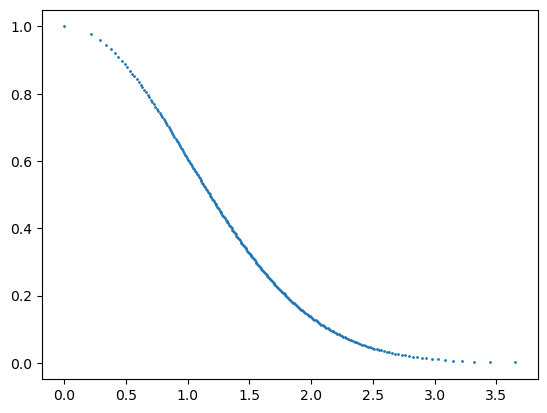

In [209]:
# Plot, and check fi
import matplotlib.pyplot as plt
plt.scatter(xi[1:], fi[1:], s=1)
yi = f(xi)
max(abs(fi[1:] - yi[1:]))

In [210]:
# Check ki:
kscaled = np.zeros(256)
kref = np.zeros(256)
kscaled[0] = ki[0]/2**expon
kscaled[1] = 0
kscaled[2:] = ki[2:]/2**expon
kref[0] = xi[255]/xi0
kref[1] = 0
kref[2:] = xi[1:-1]/xi[2:]
max(abs(kref - kscaled))

np.float64(1.1102230246251565e-16)

In [211]:
# check areas
V = np.zeros(256)
V[1:] = (fi[:-1] - fi[1:])*xi[1:]
if EXP:
    V[0] = fi[255]*r + np.exp(-r)
else:
    from scipy.stats import norm
    V[0] = fi[255]*r + np.sqrt(2*np.pi)*norm.sf(r)
V[0]
max(V) - min(V)

np.float64(2.96637714392034e-16)

In [212]:
if EXP:
    'No slope table needed for exp Dzig path'
else:
    dk = (1 << expon) - ki
    slope_norm = np.zeros(256);
    slope_norm[1:] = fi[1:]*wi[1:]*xi[1:]/(fi[:-1] - fi[1:]);
    slope_norm

array([0.0000000000000000e+00, 4.3896550726226940e-16,
       1.0134911193626061e-15, 1.6115102157997953e-15,
       2.2165084635876208e-15, 2.8230368925774006e-15,
       3.4287224974015373e-15, 4.0323637424325347e-15,
       4.6332929451917203e-15, 5.2311159579923202e-15,
       5.8255908154509878e-15, 6.4165654973161501e-15,
       7.0039436244509703e-15, 7.5876644575081429e-15,
       8.1676906988928154e-15, 8.7440007766542058e-15,
       9.3165838142669058e-15, 9.8854362682937055e-15,
       1.0450559633507355e-14, 1.1011958849086667e-14,
       1.1569641175637288e-14, 1.2123615394587600e-14,
       1.2673891232057552e-14, 1.3220478941347632e-14,
       1.3763388998952625e-14, 1.4302631882736715e-14,
       1.4838217910144791e-14, 1.5370157120635366e-14,
       1.5898459190922616e-14, 1.6423133374683833e-14,
       1.6944188460593108e-14, 1.7461632744120727e-14,
       1.7975474009687607e-14, 1.8485719520604601e-14,
       1.8992376014856136e-14, 1.9495449705248258e-14,
       1.9

In [213]:
# Compute s_i and plot secant-gap values
import matplotlib.pyplot as plt
h = np.ones(256);
l = np.zeros(256);
dx = np.ones(256);
sec = np.ones(256);
gap = np.ones(256);
h[1:] = fi[:-1] - fi[1:]
si = np.empty_like(xi)
si[0] = 0
if EXP:
    dx[1] = xi[1]
    dx[2:] = xi[2:] - xi[1:-1]
    l[1:] = dx[1:]/xi[1:];
    L = 2**expon*l
    si[1:] = np.log(dx[1:]/h[1:])
    assert 0 < si[1] < xi[1]
    assert np.all((xi[1:-1] < si[2:]) & (si[2:] < xi[2:]))
    sec[1] = 1 - si[1]*h[1]/dx[1]
    sec[2:] = fi[1:-1] - (si[2:] - xi[1:-1])*h[2:]/dx[2:]
    gap[1:] = sec[1:] - f(si[1:])
    gap[1:].min(), gap[1:].max()
else:
    dx[1:] = xi[1:] - xi[:-1]
    l[1:] = dx[1:]/xi[1:];
    L = 2**expon*l
    from scipy.special import lambertw
    arg = -(h/dx)**2
    si[xi < 1] = np.sqrt(-np.real(lambertw(arg[xi < 1], 0)))
    si[xi >= 1] = np.sqrt(-np.real(lambertw(arg[xi >= 1], -1)))
    si52 = np.sqrt(-np.real(lambertw(arg[52], 0))) # last before inflection
    assert (xi[51]**2 - 1)*f(xi[51]) < 0 and (xi[52]**2 - 1)*f(xi[52]) > 0
    sec[1:] = fi[:-1] - (si[1:] - xi[:-1])*h[1:]/dx[1:]
    sec52   = fi[51]  - (si52   - xi[51] )*h[52]/dx[52]
    gap[1:] = f(si[1:]) - sec[1:]
    gap52 = f(si52) - sec52;
    gap[52],gap52

(np.float64(-1.0218754731283752e-09), np.float64(1.1163994173557512e-08))

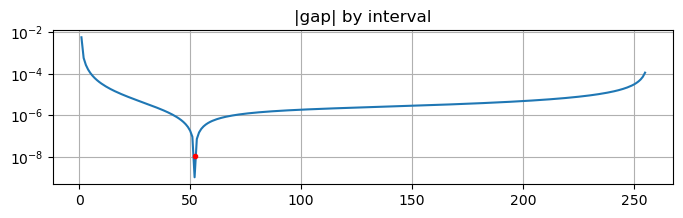

In [214]:
plt.figure(figsize=(8,2))
plt.title('|gap| by interval')
plt.semilogy(range(1,256), abs(gap[1:]))
if not EXP:
    plt.semilogy(52,abs(gap52), 'r.')
plt.grid()

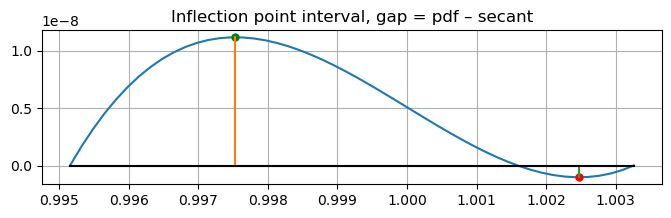

In [215]:
if EXP:
    i = np.argmax(gap[1:]) + 1
    if i == 1:
        t=np.linspace(0,xi[1])
        def sec_line(t):
            return 1 - t*h[1]/dx[1]
        xleft, xright = 0, xi[1]
    else:
        t=np.linspace(xi[i-1],xi[i])
        def sec_line(t):
            return fi[i-1] - (t-xi[i-1])*h[i]/dx[i]
        xleft, xright = xi[i-1], xi[i]
    plt.figure(figsize=(8,2))
    plt.plot(t, sec_line(t) - f(t))
    plt.plot(si[i], sec_line(si[i]) - f(si[i]), 'r.', markersize=10)
    plt.plot([si[i],si[i]], [0,gap[i]])
    plt.plot([xleft, xright], [0, 0], 'k')
    plt.title(f'Exp interval {i}, gap = secant - pdf')
    plt.grid()
else:
    t=np.linspace(xi[51],xi[52])
    def sec(t):
        s = fi[51] - (t-xi[51])*h[52]/dx[52]
        return s
    plt.figure(figsize=(8,2))
    plt.plot(t,f(t) - sec(t))
    plt.plot(si[52], f(si[52]) - sec(si[52]), 'r.', markersize=10)
    plt.plot(si52, f(si52) - sec(si52), 'g.', markersize=10)
    plt.plot([si52,si52], [0,gap52])
    plt.plot([si[52],si[52]], [0,gap[52]])
    plt.plot([xi[51], xi[52]], [0, 0], 'k')
    plt.title('Inflection point interval, gap = pdf – secant')
    plt.grid()

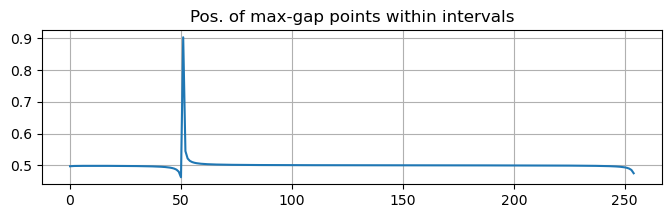

In [216]:
plt.figure(figsize=(8,2))
plt.title('Pos. of max-gap points within intervals')
if EXP:
    pos = np.zeros(256)
    pos[1] = si[1]/dx[1]
    pos[2:] = (si[2:] - xi[1:-1])/dx[2:]
    plt.plot(pos[1:])
else:
    plt.plot((si[1:] - xi[:-1])/dx[1:])
plt.grid()

In [217]:
gap = abs(gap);
if not EXP:
    gap52 = abs(gap52);

In [218]:
# Areas associated with secants and triangle-based rejection strips
V = np.mean(V)
r = xi[255]
total_area = 256*V

def area_str(a):
    return f"{a:.5f} ({100*a/total_area:.3f}%)"

if EXP:
    secant_gap_area = np.sum(gap[1:]*dx[1:])
    tail_area = np.exp(-r)
    print('Total area:              ' + area_str(total_area))
    print('Secant-gap area:         ' + area_str(secant_gap_area))
    print('Tail area:               ' + area_str(tail_area))
else:
    from scipy.stats import norm
    parallel_strip_area = np.sum(np.abs(gap[1:]*dx[1:]))
    tail_area = fi[255]*(xi0 - xi[255])
    triangle_strip_area = np.sum((xi[1:]*fi[1:]*dx[1:] - h[1:])*dx[1:]/2)
    non_tail_rej_area = np.sum(fi[:-1]*dx[1:] - np.sqrt(2*np.pi)*(norm.cdf(xi[1:]) - norm.cdf(xi[:-1])))
    non_tail_rej_rate = non_tail_rej_area / (255*V)
    tail_rej_rate = 1 - r*tail_area/fi[255]
    tail_strip_rej_rate = tail_rej_rate*tail_area/V
    mt_rect_area = np.sum(h[1:]*dx[1:])
    mt_f_evals = mt_rect_area/total_area + tail_area/total_area/(1 - tail_rej_rate)
    print('Total area:              ' + area_str(total_area))
    print('Parallel-strip area:     ' + area_str(parallel_strip_area))
    print('Tail area:               ' + area_str(tail_area))
    print('Triangle-strip area:     ' + area_str(triangle_strip_area))
    print(f"Non-tail rejection rate: {non_tail_rej_rate:.5f} ({100*non_tail_rej_rate:.3f}%)")
    print(f"Tail rejection rate:     {tail_rej_rate:.5f} ({100*tail_rej_rate:.3f}%)")
    print(f"Tail-strip reject. rate: {tail_strip_rej_rate:.5f} ({100*tail_strip_rej_rate:.3f}%")
    print(f"M-T-style f-eval_fract:  {mt_f_evals:.5f} ({100*mt_f_evals:.3f}%)")


Total area:              1.26174 (100.000%)
Parallel-strip area:     0.00135 (0.107%)
Tail area:               0.00032 (0.026%)
Triangle-strip area:     0.00244 (0.194%)
Non-tail rejection rate: 0.00670 (0.670%)
Tail rejection rate:     0.06233 (6.233%)
Tail-strip reject. rate: 0.00409 (0.409%
M-T-style f-eval_fract:  0.01494 (1.494%)


In [219]:
# xi[i] = total with of i-th strip, i=1..255
# h[i] = height of i-th strip; xi[i]*h[i] = V
# dx[i] = width of i-th slow-path-rectangle = x[i] - x[i-1]
# L[i] = slow-path width fraction = dx[i]/x[i]
# D[i] = gap*L/h = gap-multiplier for a Y = U(0,1)-draw

In [220]:
# Quantized gap constants for C header output
qdtype = np.uint32 if FLOAT else np.uint64
ctype = 'uint32_t' if FLOAT else 'uint64_t'
width = 8 if FLOAT else 16
suffix = 'UL' if FLOAT else 'ULL'
D = np.array(np.floor(L*gap/h), dtype=qdtype)
D[0] = 0
print(f'static const {ctype} Dzig[] = {{')
for k in range(0, len(D), 2):
    if k + 1 < len(D):
        print(f'  0x{int(D[k]):0{width}X}{suffix}, 0x{int(D[k+1]):0{width}X}{suffix},')
    else:
        print(f'  0x{int(D[k]):0{width}X}{suffix},')
print('};')
if not EXP:
    D52 = qdtype(np.floor(gap52*L[52]/h[52]))
    print()
    print(f'static const {ctype} Dzig52 = 0x{int(D52):0{width}X}{suffix};')

static const uint64_t Dzig[] = {
  0x0000000000000000ULL, 0x0003F71F483EEB2CULL,
  0x000021A9106A8C92ULL, 0x00000AE25B3F6FE3ULL,
  0x0000053459B97135ULL, 0x000002FF9FA46B6FULL,
  0x000001ED871F4980ULL, 0x0000015513551A73ULL,
  0x000000F814418A87ULL, 0x000000BB6E23B6ACULL,
  0x00000091D274974EULL, 0x000000741EB10FBEULL,
  0x0000005E3A2E9469ULL, 0x0000004DA90B41D0ULL,
  0x00000040D813F8DCULL, 0x00000036BDEC25DAULL,
  0x0000002EA6565E77ULL, 0x00000028138AEFCBULL,
  0x00000022ABADD81FULL, 0x0000001E2D37683AULL,
  0x0000001A677DE355ULL, 0x0000001735C77F3FULL,
  0x000000147BF569E9ULL, 0x00000012243758DFULL,
  0x000000101D6E0DB7ULL, 0x0000000E5A03EA75ULL,
  0x0000000CCF16A8B5ULL, 0x0000000B73D9C1B6ULL,
  0x0000000A41210E05ULL, 0x000000093108534CULL,
  0x000000083EAFE696ULL, 0x000000076608D979ULL,
  0x00000006A3ACBD72ULL, 0x00000005F4BE2136ULL,
  0x0000000556CFB087ULL, 0x00000004C7D06B01ULL,
  0x0000000445FBCAE1ULL, 0x00000003CFCCFD88ULL,
  0x0000000363F4852BULL, 0x00000003014FC29CULL,
  0x000

In [221]:
L[254]/2**expon,h[254],gap[254],D[254]/2**expon

(np.float64(0.03740885876776625),
 np.float64(0.0014288998472608643),
 np.float64(7.099913675710475e-05),
 np.float64(0.0018587703572585657))